# Gözetimsiz Öğrenme ile Müşteri Segmentasyonu
## Bölümleme (Partitional) Kümeleme: **K-Means** Çalışması

> **Belge türü:** Teknik analiz raporu & yeniden üretilebilir çalışma defteri
> **Alan:** Veri Bilimi / Gözetimsiz Makine Öğrenmesi
> **Yöntem:** K-Means (`sklearn.cluster.KMeans`, `k-means++` başlatma)
> **Veri:** `mall_customer_behavior.csv` (1.610 müşteri) — *DBSCAN/HDBSCAN çalışmasıyla aynı veri seti*

---

**Ana bulgular:**
1. Beş bağımsız yöntem (**Elbow, Silhouette, Davies–Bouldin, Calinski–Harabasz, Gap istatistiği**) **`k = 5`** üzerinde buluşur.
2. Veri temelde Gauss-benzeri öbeklerden oluştuğu için, **doğru `k` ile K-Means çok iyi çalışır** (ARI ≈ 0.87) — hatta bu metrikte HDBSCAN'i hafifçe geçer.
3. **Kritik dezavantaj:** K-Means'in gürültü kavramı yoktur; veri setindeki ~90 aykırı müşteriyi zorla kümelere dağıtarak **segmentleri kirletir**. HDBSCAN bu müşterileri `-1` olarak ayırabiliyordu.

> **Çıkarım:** Kümelerin yaklaşık küresel olduğu ve gürültünün az/yönetilebilir olduğu durumlarda K-Means hızlı ve güçlü bir varsayılandır. Gürültü ve değişken yoğunluk baskınsa yoğunluk-temelli yöntemler tercih edilmelidir.


## 1. Ortam ve Kütüphaneler

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, adjusted_mutual_info_score,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
RANDOM_STATE = 42

import sklearn
print("numpy        :", np.__version__)
print("pandas       :", pd.__version__)
print("scikit-learn :", sklearn.__version__)
print("\nKMeans hazir (k-means++ varsayilan baslatma).")

numpy        : 2.4.4
pandas       : 3.0.2
scikit-learn : 1.8.0

KMeans hazir (k-means++ varsayilan baslatma).


## 2. Veri Yükleme ve Veri Sözlüğü

DBSCAN/HDBSCAN çalışmasıyla **aynı** veri seti kullanılır (karşılaştırma adil olsun diye). Eşdeğer gerçek veri seti:

- **Mall Customer Segmentation Data** — `vjchoudhary7` · <https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python>

| Sütun | Açıklama |
|---|---|
| `customer_id` | Benzersiz müşteri kimliği |
| `gender` | Cinsiyet |
| `age` | Yaş |
| `annual_income_kusd` | Yıllık gelir |
| `spending_score` | Harcama skoru (1–100) |
| `purchase_freq_yr` | Yıllık satın alma sayısı |
| `avg_basket_usd` | Ortalama sepet tutarı  |
| `avg_session_min` | Ortalama oturum süresi (dk) |
| `online_ratio` | Çevrimiçi alışveriş oranı (0–1) |
| `loyalty_years` | Sadakat süresi (yıl) |
| `true_segment` | **Yalnızca doğrulama için** gerçek segment (modellemede KULLANILMAZ) |


In [2]:
DATA_PATH = "mall_customer_behavior.csv"
df = pd.read_csv(DATA_PATH)
print(f"Veri seti yuklendi: {df.shape[0]:,} musteri x {df.shape[1]} sutun")
df.head()

Veri seti yuklendi: 1,610 musteri x 11 sutun


,customer_id,gender,age,annual_income_kusd,spending_score,purchase_freq_yr,avg_basket_usd,avg_session_min,online_ratio,loyalty_years,true_segment
0,11315,Male,53,95.9,25,5.6,187.86,16.4,0.420,5.6,Affluent Savers
1,10559,Female,39,92.0,91,15.6,230.15,30.4,0.486,3.2,Premium Loyalists
2,10201,Male,52,58.1,52,7.3,128.55,28.2,0.407,5.5,Mainstream
3,10271,Male,25,74.4,57,7.2,152.66,24.0,0.725,3.2,Mainstream
4,11513,Male,23,54.8,68,11.1,161.18,15.4,0.619,3.9,Young Aspirational


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1610 non-null   int64  
 1   gender              1610 non-null   str    
 2   age                 1610 non-null   int64  
 3   annual_income_kusd  1610 non-null   float64
 4   spending_score      1610 non-null   int64  
 5   purchase_freq_yr    1610 non-null   float64
 6   avg_basket_usd      1610 non-null   float64
 7   avg_session_min     1610 non-null   float64
 8   online_ratio        1598 non-null   float64
 9   loyalty_years       1610 non-null   float64
 10  true_segment        1610 non-null   str    
dtypes: float64(6), int64(3), str(2)
memory usage: 138.5 KB


In [4]:
df.select_dtypes("number").describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,1610.0,10805.50,464.91,10001.00,10403.25,10805.50,11207.75,11610.00
age,1610.0,40.04,11.70,18.00,31.00,40.00,48.00,75.00
annual_income_kusd,1610.0,58.66,25.20,-5.10,33.10,58.70,84.40,102.30
spending_score,1610.0,50.18,24.84,1.00,27.00,49.00,76.00,100.00
purchase_freq_yr,1610.0,8.35,3.93,0.50,5.32,8.30,11.30,19.20
avg_basket_usd,1610.0,133.50,55.96,10.00,94.17,132.58,173.78,304.12
avg_session_min,1610.0,20.42,8.00,1.00,14.50,20.20,26.40,45.30
online_ratio,1598.0,0.50,0.17,0.02,0.38,0.50,0.62,0.99
loyalty_years,1610.0,4.43,1.96,0.00,3.10,4.40,5.80,11.40


## 3. Keşifsel Veri Analizi (EDA)

In [5]:
miss = df.isna().sum()
print("Eksik degerler:")
print(miss[miss > 0] if (miss > 0).any() else "  Yok")
print("\nYinelenen satir:", df.duplicated().sum())
print("\nGercek segment dagilimi (yalniz dogrulama):")
print(df["true_segment"].value_counts())

Eksik degerler:
online_ratio    12
dtype: int64

Yinelenen satir: 0

Gercek segment dagilimi (yalniz dogrulama):
true_segment
Mainstream            520
Premium Loyalists     300
Budget Conscious      300
Affluent Savers       220
Young Aspirational    180
Noise                  90
Name: count, dtype: int64


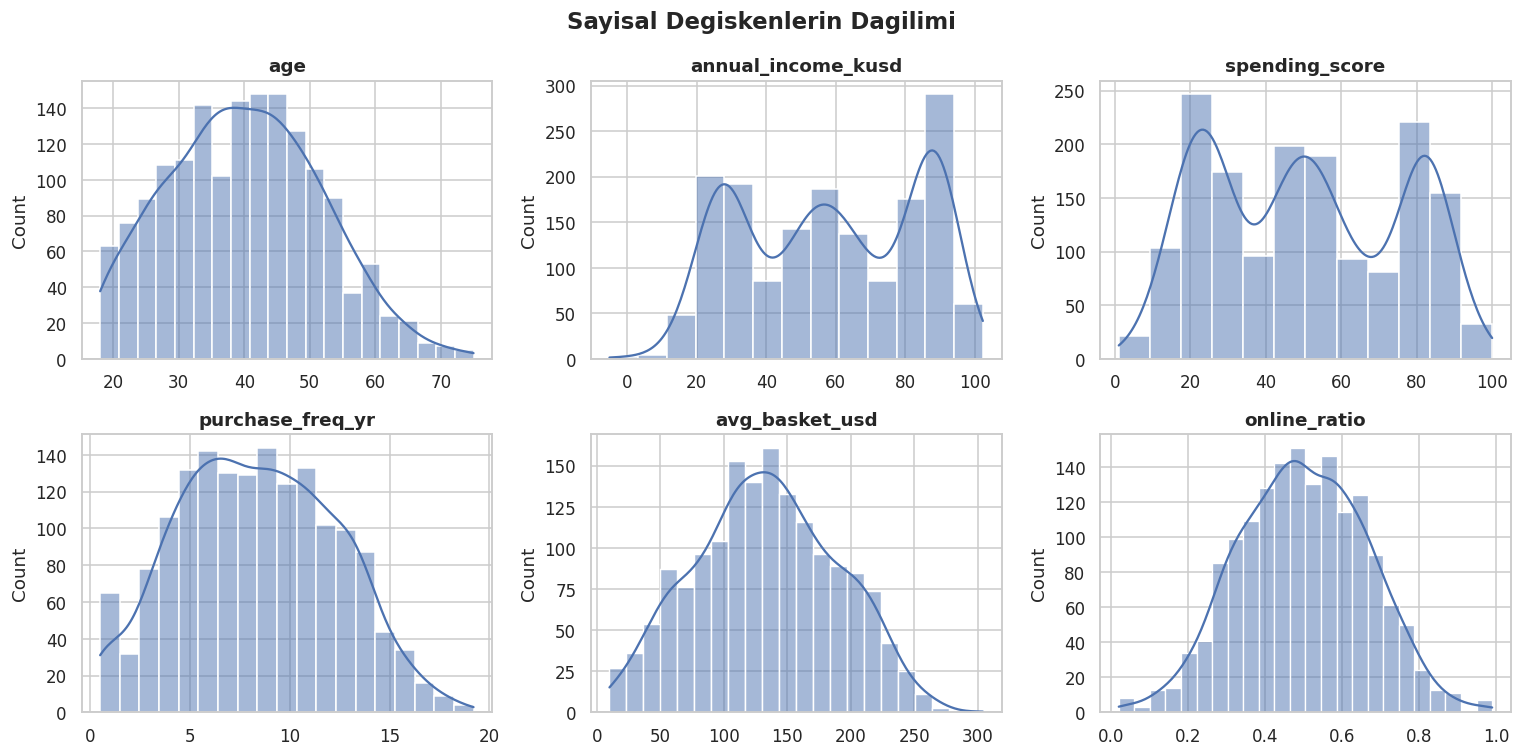

In [6]:
num_cols = ["age", "annual_income_kusd", "spending_score",
            "purchase_freq_yr", "avg_basket_usd", "online_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_title(c); ax.set_xlabel("")
fig.suptitle("Sayisal Degiskenlerin Dagilimi", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

Gelir ve harcama skorunun çok-modlu dağılımları ayrık öbeklere işaret ediyor. Analistin gördüğü etiketsiz dağılım:

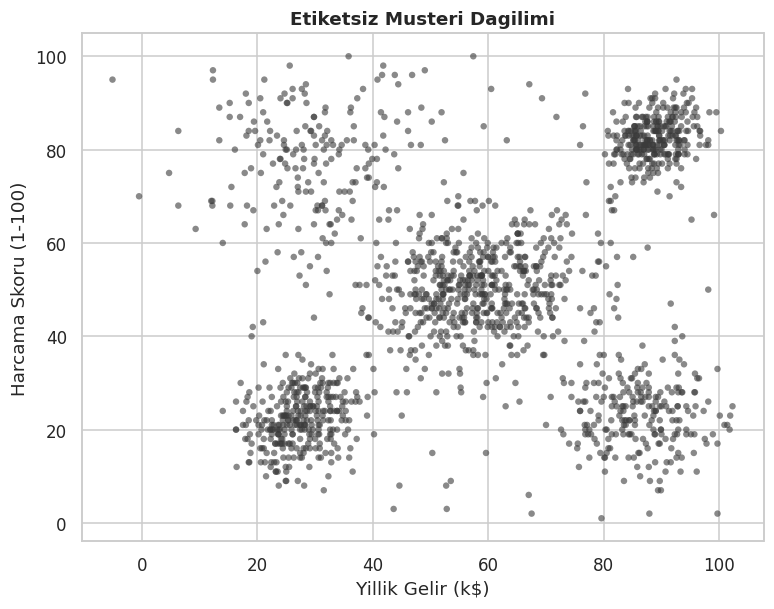

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["annual_income_kusd"], df["spending_score"],
           s=18, alpha=0.6, color="#3b3b3b", edgecolor="none")
ax.set_xlabel("Yillik Gelir (k$)"); ax.set_ylabel("Harcama Skoru (1-100)")
ax.set_title("Etiketsiz Musteri Dagilimi")
plt.show()

Öbekler **kabaca dışbükey/yuvarlak** görünüyor — bu, K-Means'in başarılı olması için olumlu bir işaret. Ancak serpiştirilmiş aykırı noktalara dikkat: K-Means bunları gürültü olarak işaretleyemeyecek, bir kümeye atayacaktır.

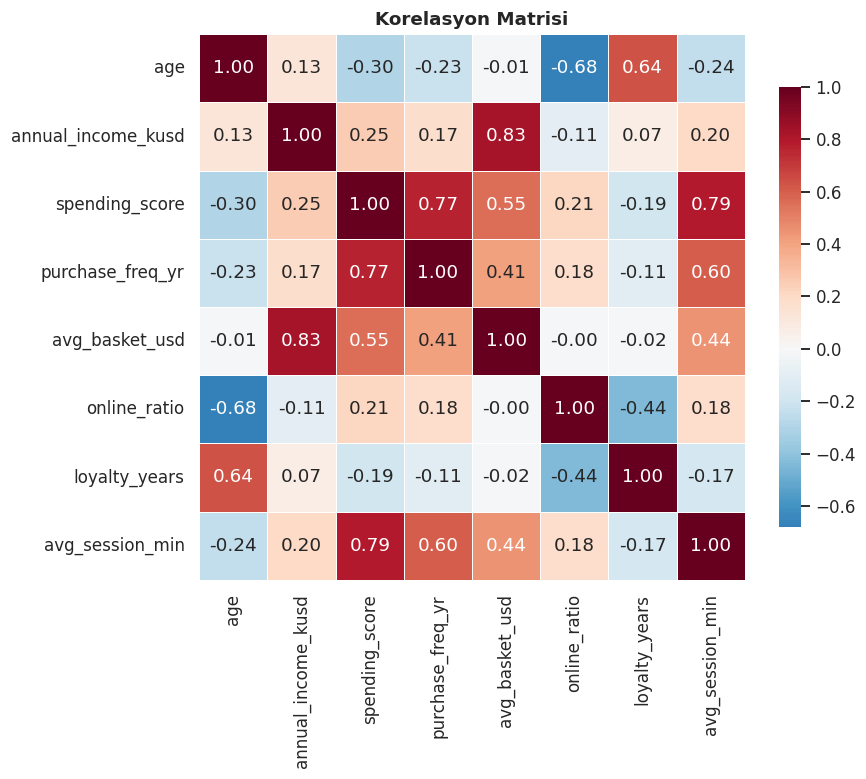

In [8]:
corr_cols = num_cols + ["loyalty_years", "avg_session_min"]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Korelasyon Matrisi")
plt.show()

## 4. Veri Önişleme

K-Means Öklid mesafesi kullandığından **standardizasyon kritiktir**: ölçeklenmezse gelir (~100) harcama skorunu (~50) ezerek merkezleri çarpıtır.


In [9]:
df["online_ratio"] = df["online_ratio"].fillna(df["online_ratio"].median())

CLUSTER_FEATURES = ["annual_income_kusd", "spending_score"]
scaler = StandardScaler()
X = scaler.fit_transform(df[CLUSTER_FEATURES])
y_true = df["true_segment"].values

print("Olceklendi -> ortalama ~ 0, std ~ 1")
pd.DataFrame(X, columns=CLUSTER_FEATURES).describe().round(3).loc[["mean", "std", "min", "max"]]

Olceklendi -> ortalama ~ 0, std ~ 1


,annual_income_kusd,spending_score
mean,-0.000,0.000
std,1.000,1.000
min,-2.531,-1.980
max,1.732,2.006


In [10]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
           "#8172B3", "#937860", "#DA8BC3", "#CCB974"]

def plot_clusters(ax, labels, title, centroids=None):
    # Kumeleri gelir-harcama duzleminde cizer; -1 etiketi (gurultu) gri 'x'.
    for i, lab in enumerate(sorted(set(labels))):
        m = labels == lab
        if lab == -1:
            ax.scatter(df.loc[m, "annual_income_kusd"], df.loc[m, "spending_score"],
                       s=16, c="lightgray", marker="x", alpha=0.6, label="Gurultu (-1)")
        else:
            ax.scatter(df.loc[m, "annual_income_kusd"], df.loc[m, "spending_score"],
                       s=24, c=PALETTE[i % len(PALETTE)], alpha=0.75,
                       edgecolor="white", linewidth=0.3, label=f"Kume {lab}")
    if centroids is not None:
        ax.scatter(centroids[:, 0], centroids[:, 1], s=260, c="black",
                   marker="X", edgecolor="white", linewidth=1.5, zorder=5,
                   label="Merkez (centroid)")
    ax.set_xlabel("Yillik Gelir (k$)"); ax.set_ylabel("Harcama Skoru")
    ax.set_title(title); ax.legend(fontsize=8, markerscale=1.1, framealpha=0.9)

print("plot_clusters() hazir.")

plot_clusters() hazir.


## 5. Optimal `k` Seçimi (5 Bağımsız Yöntem)

`k` tek bir yönteme göre değil, **birden çok ölçütün uzlaşısıyla** seçilmelidir. Beş yöntemi `k = 2..10` için hesaplıyoruz.


In [11]:
K_RANGE = range(2, 11)
inertias, sils, dbs, chs = [], [], [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))
    dbs.append(davies_bouldin_score(X, km.labels_))
    chs.append(calinski_harabasz_score(X, km.labels_))

metrics_tbl = pd.DataFrame({
    "k": list(K_RANGE), "inertia": np.round(inertias, 1),
    "silhouette": np.round(sils, 3), "davies_bouldin": np.round(dbs, 3),
    "calinski_harabasz": np.round(chs, 1),
}).set_index("k")
metrics_tbl

,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,1921.0,0.367,1.132,1087.3
3,1231.1,0.419,0.950,1298.2
4,653.7,0.557,0.627,2101.5
5,312.8,0.632,0.513,3729.0
6,263.4,0.548,0.698,3601.4
7,237.6,0.529,0.831,3353.1
8,212.7,0.519,0.801,3235.4
9,196.1,0.521,0.785,3086.2
10,181.6,0.509,0.780,2975.1


### 5.1 Elbow (Dirsek) Yöntemi
Inertia, `k` arttıkça azalır; azalmanın yavaşladığı **"dirsek"** makul `k`'dir. Dirseği objektif belirlemek için kiriş (chord) yöntemini kullanıyoruz.

Elbow -> k = 10


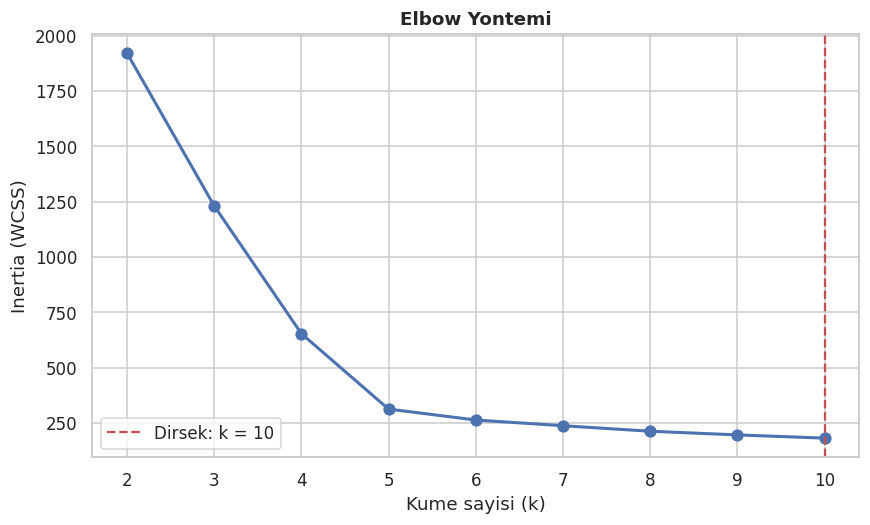

In [12]:
ks = np.array(list(K_RANGE))
xn = (ks - ks.min()) / (ks.max() - ks.min())
yn = (np.array(inertias) - min(inertias)) / (max(inertias) - min(inertias))
elbow_k = int(ks[np.argmax(xn - yn)])  # kiristen en uzak nokta

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ks, inertias, "o-", color="#4C72B0", lw=2, ms=7)
ax.axvline(elbow_k, color="#C44E52", ls="--", label=f"Dirsek: k = {elbow_k}")
ax.set_xlabel("Kume sayisi (k)"); ax.set_ylabel("Inertia (WCSS)")
ax.set_title("Elbow Yontemi")
ax.legend()
plt.show()
print("Elbow -> k =", elbow_k)

### 5.2 Silhouette, Davies–Bouldin ve Calinski–Harabasz

Silhouette->5 | Davies-Bouldin->5 | Calinski-Harabasz->5


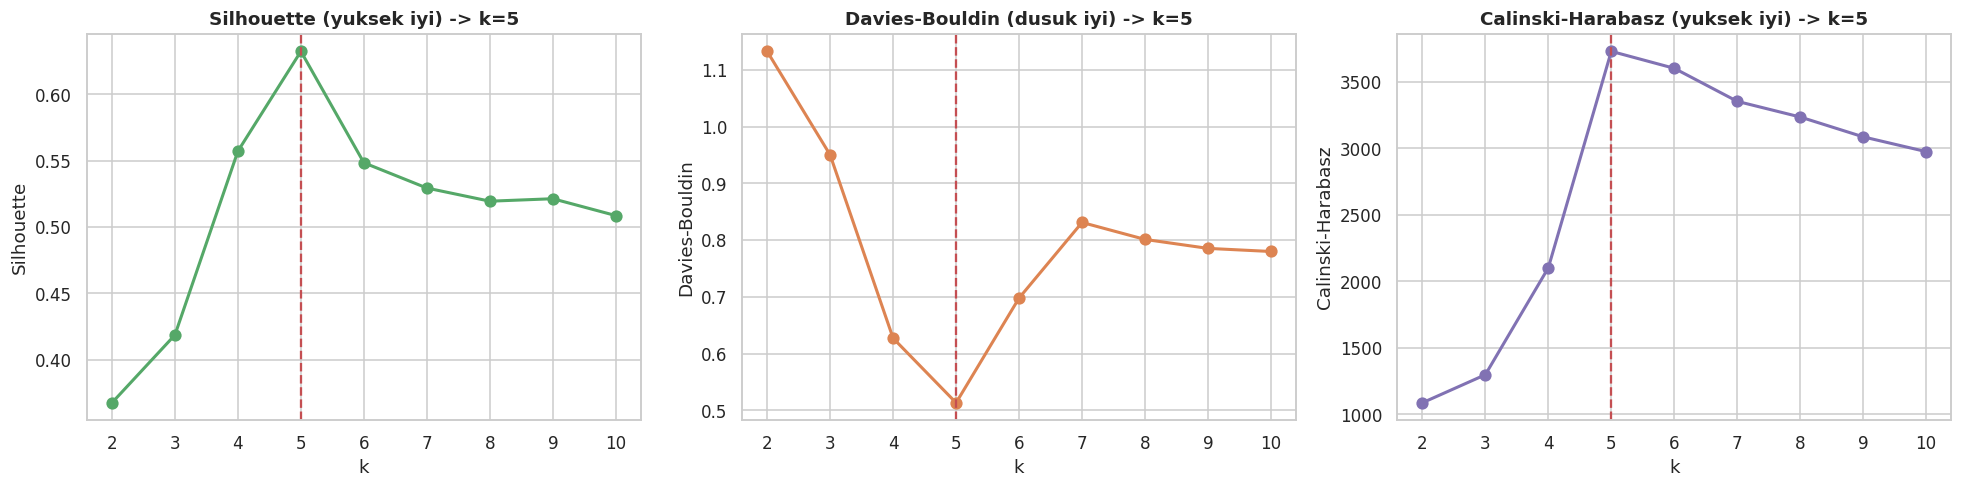

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
best_sil = ks[int(np.argmax(sils))]
best_db  = ks[int(np.argmin(dbs))]
best_ch  = ks[int(np.argmax(chs))]

axes[0].plot(ks, sils, "o-", color="#55A868", lw=2, ms=7)
axes[0].axvline(best_sil, color="#C44E52", ls="--")
axes[0].set_title(f"Silhouette (yuksek iyi) -> k={best_sil}")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Silhouette")

axes[1].plot(ks, dbs, "o-", color="#DD8452", lw=2, ms=7)
axes[1].axvline(best_db, color="#C44E52", ls="--")
axes[1].set_title(f"Davies-Bouldin (dusuk iyi) -> k={best_db}")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Davies-Bouldin")

axes[2].plot(ks, chs, "o-", color="#8172B3", lw=2, ms=7)
axes[2].axvline(best_ch, color="#C44E52", ls="--")
axes[2].set_title(f"Calinski-Harabasz (yuksek iyi) -> k={best_ch}")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Calinski-Harabasz")

fig.tight_layout()
plt.show()
print(f"Silhouette->{best_sil} | Davies-Bouldin->{best_db} | Calinski-Harabasz->{best_ch}")

### 5.3 Gap İstatistiği
Gözlenen WCSS'i, **rastgele tekdüze (uniform) referans veri** üzerindeki beklenen WCSS ile kıyaslar. Gap'in doygunluğa ulaştığı (artışın ihmal edilebilir hâle geldiği) `k` seçilir.

Gap k=4->5 sicramasi: 0.547 | k=5->6 kazanci: 0.003 (ihmal edilebilir)


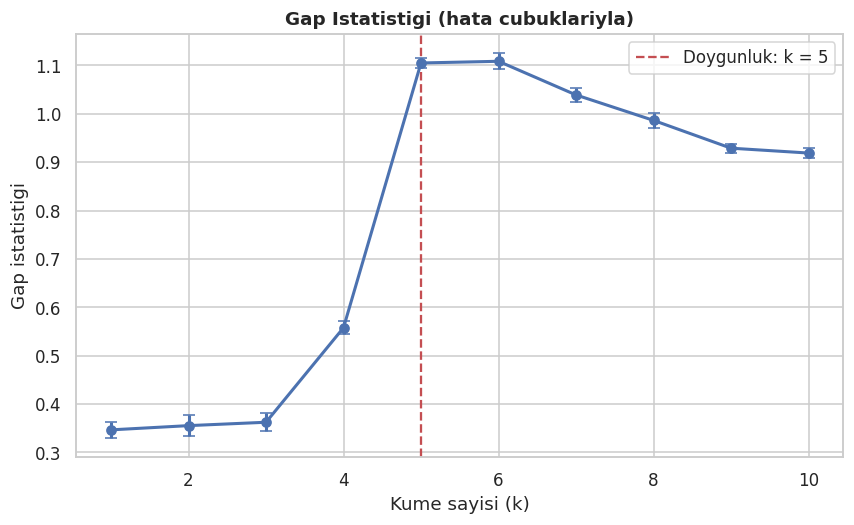

In [14]:
rng = np.random.default_rng(RANDOM_STATE)
mins, maxs = X.min(0), X.max(0)
B = 10
gap_ks = range(1, 11)
gaps, sk = [], []
for k in gap_ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    log_wk = np.log(km.inertia_)
    refs = []
    for b in range(B):
        Xr = rng.uniform(mins, maxs, size=X.shape)
        refs.append(np.log(KMeans(n_clusters=k, n_init=5, random_state=b).fit(Xr).inertia_))
    gaps.append(np.mean(refs) - log_wk)
    sk.append(np.std(refs) * np.sqrt(1 + 1 / B))

gaps, sk = np.array(gaps), np.array(sk)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(list(gap_ks), gaps, yerr=sk, fmt="o-", color="#4C72B0", lw=2, capsize=4)
ax.axvline(5, color="#C44E52", ls="--", label="Doygunluk: k = 5")
ax.set_xlabel("Kume sayisi (k)"); ax.set_ylabel("Gap istatistigi")
ax.set_title("Gap Istatistigi (hata cubuklariyla)")
ax.legend()
plt.show()
print("Gap k=4->5 sicramasi:", round(gaps[4] - gaps[3], 3),
      "| k=5->6 kazanci:", round(gaps[5] - gaps[4], 3), "(ihmal edilebilir)")

### 5.4 Uzlaşı
Beş yöntem de **`k = 5`** sonucunda buluşuyor (Gap, k=5'ten sonra doygunluğa ulaşır; k=6 kazancı bir standart hatanın içinde kalır). Yöntemlerin bu denli net örtüşmesi, veride **5 doğal segment** bulunduğuna dair güçlü kanıttır.

## 6. K-Means Modelleme

`k = 5`, `k-means++` başlatma ve `n_init = 10` ile nihai modeli kuruyoruz. `n_init`, 10 farklı başlatmadan en düşük *inertia*'lıyı seçerek başlatma riskini azaltır.


In [15]:
K = 5
kmeans = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=RANDOM_STATE)
km_labels = kmeans.fit_predict(X)
df["kmeans"] = km_labels

print(f"K-Means: k={K}, init=k-means++, n_init=10")
print(f"  Inertia (WCSS)   : {kmeans.inertia_:.1f}")
print(f"  Iterasyon sayisi : {kmeans.n_iter_}")
print(f"  Kume buyuklukleri: {dict(pd.Series(km_labels).value_counts().sort_index())}")

K-Means: k=5, init=k-means++, n_init=10
  Inertia (WCSS)   : 312.8
  Iterasyon sayisi : 5
  Kume buyuklukleri: {0: np.int64(327), 1: np.int64(528), 2: np.int64(241), 3: np.int64(320), 4: np.int64(194)}


## 7. Görselleştirme: Kümeler, Merkezler ve Karar Sınırı

K-Means'in en güçlü özelliği **yorumlanabilir merkezlerdir** (centroid). Merkezleri orijinal birimlere (gelir $, harcama skoru) geri dönüştürüp segment "tipik profilini" okuyabiliriz.


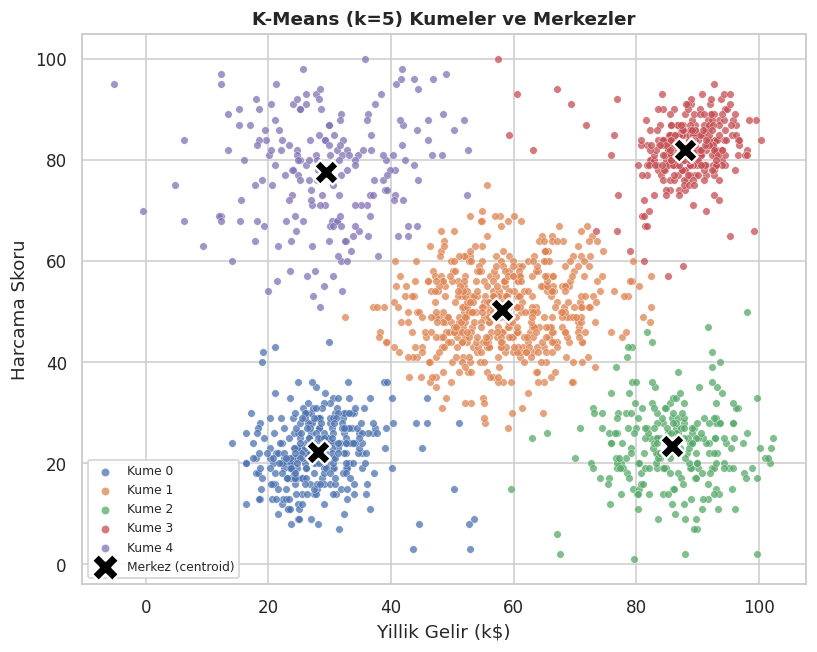

In [16]:
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
fig, ax = plt.subplots(figsize=(8.5, 6.5))
plot_clusters(ax, km_labels, f"K-Means (k={K}) Kumeler ve Merkezler",
              centroids=centroids_orig)
plt.show()

### 7.1 Karar Sınırı (Voronoi Bölmeleme)
K-Means, uzayı **dışbükey çokgenlere (Voronoi hücreleri)** böler: her nokta en yakın merkeze gider. Bu, yöntemin temel geometrik varsayımını görselleştirir — kümeler ancak dışbükey biçimlerle iyi yakalanır.

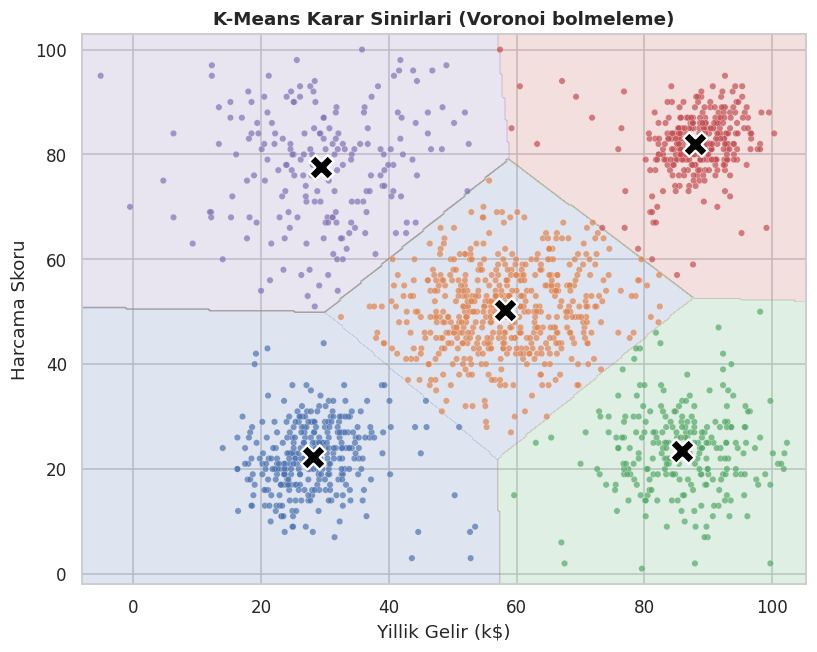

In [17]:
inc = np.linspace(df["annual_income_kusd"].min() - 3, df["annual_income_kusd"].max() + 3, 350)
spd = np.linspace(df["spending_score"].min() - 3, df["spending_score"].max() + 3, 350)
xx, yy = np.meshgrid(inc, spd)
grid = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
Z = kmeans.predict(grid).reshape(xx.shape)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(PALETTE[:K])
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.contourf(xx, yy, Z, alpha=0.18, cmap=cmap)
ax.scatter(df["annual_income_kusd"], df["spending_score"],
           c=[PALETTE[l] for l in km_labels], s=18, alpha=0.7,
           edgecolor="white", linewidth=0.2)
ax.scatter(centroids_orig[:, 0], centroids_orig[:, 1], s=260, c="black",
           marker="X", edgecolor="white", linewidth=1.5, zorder=5)
ax.set_xlabel("Yillik Gelir (k$)"); ax.set_ylabel("Harcama Skoru")
ax.set_title("K-Means Karar Sinirlari (Voronoi bolmeleme)")
plt.show()

### 7.2 Silhouette Analizi
Her kümenin iç tutarlılığı ayrı ayrı: geniş ve ortalamanın üstünde bloklar iyi ayrışmış kümeleri gösterir.

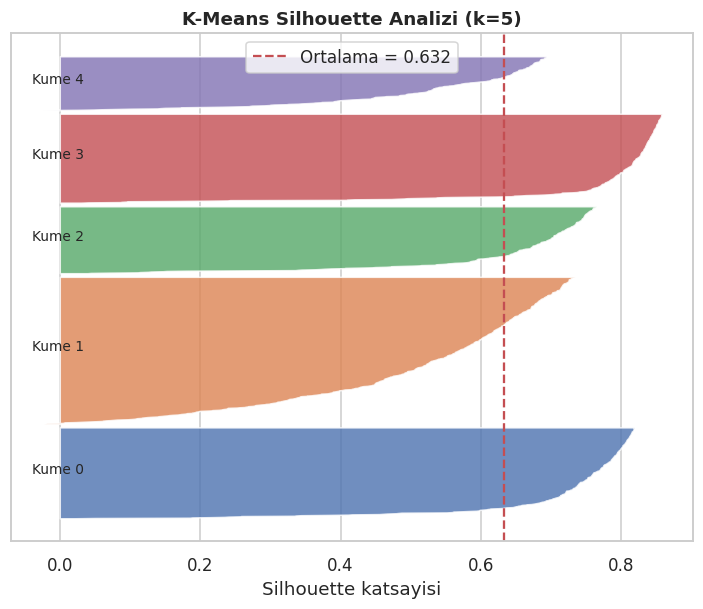

In [18]:
sample_sil = silhouette_samples(X, km_labels)
avg_sil = silhouette_score(X, km_labels)
fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(K):
    vals = np.sort(sample_sil[km_labels == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=PALETTE[i], alpha=0.8)
    ax.text(-0.04, y_lower + 0.5 * len(vals), f"Kume {i}", fontsize=9)
    y_lower = y_upper + 12
ax.axvline(avg_sil, color="#C44E52", ls="--", label=f"Ortalama = {avg_sil:.3f}")
ax.set_xlabel("Silhouette katsayisi"); ax.set_yticks([])
ax.set_title(f"K-Means Silhouette Analizi (k={K})")
ax.legend()
plt.show()

## 8. Değerlendirme ve Doğrulama


In [19]:
def eval_clustering(name, labels):
    k = len(set(labels)) - (1 if -1 in labels else 0)
    m = labels != -1
    ok = (k > 1 and m.sum() > k)
    return {
        "Algoritma": name, "Kume": k,
        "Gurultu %": round(100 * (labels == -1).mean(), 1),
        "Silhouette": round(silhouette_score(X[m], labels[m]), 3) if ok else np.nan,
        "Davies-Bouldin": round(davies_bouldin_score(X[m], labels[m]), 3) if ok else np.nan,
        "Calinski-Harabasz": round(calinski_harabasz_score(X[m], labels[m]), 1) if ok else np.nan,
        "ARI": round(adjusted_rand_score(y_true, labels), 3),
        "AMI": round(adjusted_mutual_info_score(y_true, labels), 3),
    }

km_eval = pd.DataFrame([eval_clustering("K-Means (k=5)", km_labels)]).set_index("Algoritma")
km_eval

,Kume,Gurultu %,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,AMI
Algoritma,,,,,,,
K-Means (k=5),5,0.0,0.632,0.513,3729.0,0.874,0.838


### 8.1 Gerçek Segmentlerle Çapraz Tablo — Gürültü Kirliliği
K-Means'in gürültü kavramı olmadığı için, gerçekte **gürültü** olan ~90 müşteri zorla kümelere dağılır. Aşağıdaki çapraz tabloda `Noise` satırının tüm kümelere yayıldığına dikkat edin — bu, segmentlerin gerçek bir **kirlenme maliyetidir**.

In [20]:
ct = pd.crosstab(df["kmeans"], df["true_segment"])
ct

true_segment,Affluent Savers,Budget Conscious,Mainstream,Noise,Premium Loyalists,Young Aspirational
kmeans,,,,,,
0,0,300,7,20,0,0
1,3,0,498,21,0,6
2,217,0,7,17,0,0
3,0,0,5,12,300,3
4,0,0,3,20,0,171


In [21]:
noise_spread = ct.loc[:, "Noise"]
print("Gercek 'Noise' musterilerinin K-Means kumelerine dagilimi:")
print(noise_spread)
print(f"\nToplam {int(noise_spread.sum())} gurultu musterisi, "
      f"{(noise_spread > 0).sum()} farkli kumeye zorla atandi.")
print("HDBSCAN bu musterileri -1 (gurultu) olarak ayirabiliyordu.")

Gercek 'Noise' musterilerinin K-Means kumelerine dagilimi:
kmeans
0    20
1    21
2    17
3    12
4    20
Name: Noise, dtype: int64

Toplam 90 gurultu musterisi, 5 farkli kumeye zorla atandi.
HDBSCAN bu musterileri -1 (gurultu) olarak ayirabiliyordu.


## 9. Başlatma Kararlılığı: `k-means++` Neden Önemli?

K-Means yerel minimuma takılabilir. Saf **rastgele başlatma** ile `n_init=1` çok değişken sonuçlar verirken, `k-means++` + yüksek `n_init` sonucu kararlı kılar. Bunu 30 farklı tohumla gösteriyoruz.


Rastgele baslatma  -> inertia [313, 313], ARI std=0.001
k-means++ (n_init=10) -> inertia 313 (kararli)


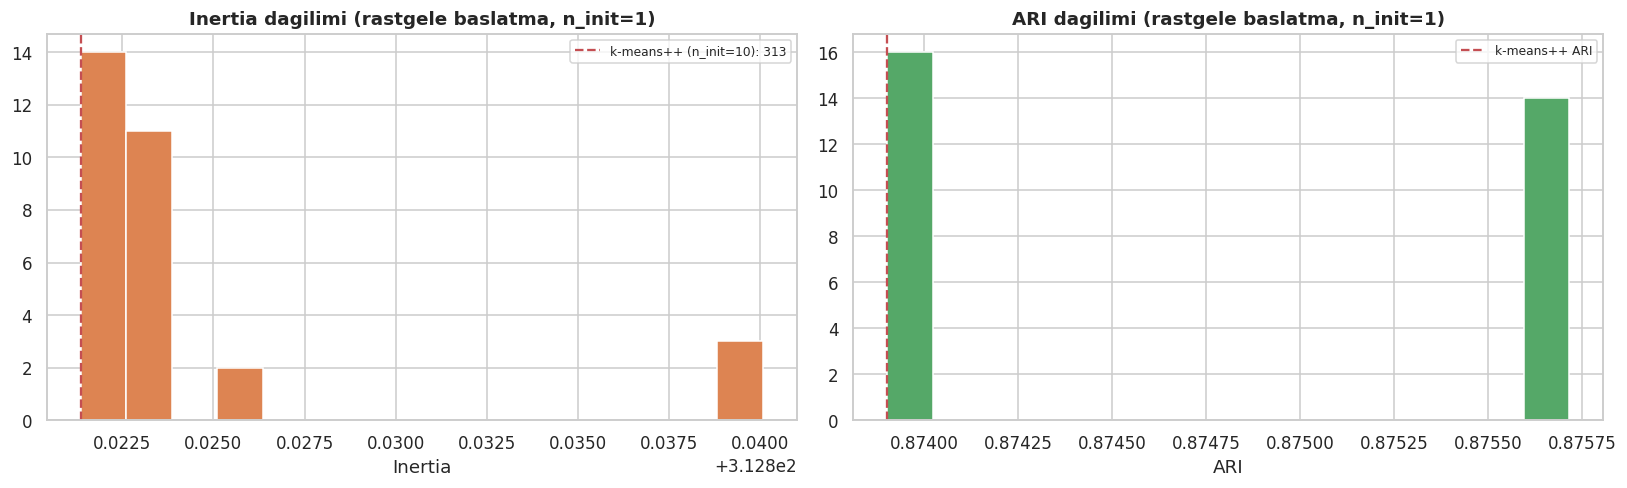

In [22]:
seeds = range(30)
rand_inertia, rand_ari = [], []
for s in seeds:
    km = KMeans(n_clusters=K, init="random", n_init=1, random_state=s).fit(X)
    rand_inertia.append(km.inertia_)
    rand_ari.append(adjusted_rand_score(y_true, km.labels_))

stable = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=RANDOM_STATE).fit(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
axes[0].hist(rand_inertia, bins=15, color="#DD8452", edgecolor="white")
axes[0].axvline(stable.inertia_, color="#C44E52", ls="--",
                label=f"k-means++ (n_init=10): {stable.inertia_:.0f}")
axes[0].set_title("Inertia dagilimi (rastgele baslatma, n_init=1)")
axes[0].set_xlabel("Inertia"); axes[0].legend(fontsize=8)

axes[1].hist(rand_ari, bins=15, color="#55A868", edgecolor="white")
axes[1].axvline(adjusted_rand_score(y_true, stable.labels_), color="#C44E52", ls="--",
                label="k-means++ ARI")
axes[1].set_title("ARI dagilimi (rastgele baslatma, n_init=1)")
axes[1].set_xlabel("ARI"); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Rastgele baslatma  -> inertia [{min(rand_inertia):.0f}, {max(rand_inertia):.0f}], "
      f"ARI std={np.std(rand_ari):.3f}")
print(f"k-means++ (n_init=10) -> inertia {stable.inertia_:.0f} (kararli)")

Rastgele başlatmada inertia ve ARI ciddi şekilde dalgalanır; `k-means++` + `n_init=10` bu riski neredeyse ortadan kaldırır. **Üretimde her zaman `k-means++` ve `n_init ≥ 10` kullanın.**

## 10. Küme Profilleme ve İş Önerileri

Merkezleri orijinal birimlerde okuyup, kümeleri tüm davranışsal değişkenlerle profilliyoruz.


In [23]:
centroid_tbl = pd.DataFrame(centroids_orig, columns=["gelir_k$", "harcama_skoru"]).round(1)
centroid_tbl.index.name = "kume"
print("Merkezler (orijinal birimler):")
centroid_tbl

Merkezler (orijinal birimler):


,gelir_k$,harcama_skoru
kume,,
0,28.1,22.3
1,58.1,50.2
2,85.8,23.5
3,88.0,82.0
4,29.4,77.7


In [24]:
profile_cols = ["age", "annual_income_kusd", "spending_score",
                "purchase_freq_yr", "avg_basket_usd", "online_ratio", "loyalty_years"]
profile = df.groupby("kmeans")[profile_cols].mean().round(1)
profile["musteri_sayisi"] = df.groupby("kmeans").size()
profile

,age,annual_income_kusd,spending_score,purchase_freq_yr,avg_basket_usd,online_ratio,loyalty_years,musteri_sayisi
kmeans,,,,,,,,
0,45.1,28.1,22.3,5.2,61.1,0.4,5.0,327
1,38.0,58.1,50.2,8.2,133.2,0.5,4.2,528
2,45.8,85.8,23.5,4.9,153.7,0.4,5.1,241
3,40.9,88.0,82.0,12.3,208.5,0.5,4.4,320
4,28.5,29.4,77.7,11.8,107.5,0.6,3.2,194


### Segment Yorumları ve Aksiyonlar

| Küme | İş Segmenti | Karakter | Önerilen Aksiyon |
|---|---|---|---|
| Yüksek gelir + yüksek harcama | **Premium Sadıklar** | En değerli, sık alışveriş | VIP program, erken erişim, kişisel ilişki yönetimi |
| Düşük gelir + düşük harcama | **Bütçe Odaklılar** | Fiyat hassas | İndirim/kupon, fiyat-değer mesajı |
| Yüksek gelir + düşük harcama | **Tutumlu Varlıklılar** | Potansiyel yüksek | Premium keşif, çapraz satış |
| Düşük gelir + yüksek harcama | **Genç Hevesliler** | Genç, çevrimiçi, aspirasyonel | Sosyal medya, taksit/BNPL, trend ürünler |
| Orta gelir + orta harcama | **Ana Akım** | En kalabalık, dengeli | Genel kampanya, sepet büyütme |

> **K-Means'e özgü uyarı:** Yukarıdaki segmentler ~90 gürültü müşterisini de içerir (ayrılamadı). Aktivasyon öncesi, merkeze uzaklığı yüksek (düşük güvenli) müşterileri ayrı bir liste olarak ele almak iyi bir pratiktir — bu, HDBSCAN'in `-1` etiketi ve üyelik olasılığının K-Means'te elle yeniden üretilmesidir.


In [25]:
# Merkeze uzaklik = dusuk guven proxy'si; en uzak %5'i "supheli" olarak isaretle
dist_to_centroid = np.linalg.norm(X - kmeans.cluster_centers_[km_labels], axis=1)
thr = np.quantile(dist_to_centroid, 0.95)
df["km_uzaklik"] = dist_to_centroid.round(3)
df["km_supheli"] = dist_to_centroid > thr
print(f"Merkeze uzaklik esigi (%95): {thr:.3f}")
print(f"Supheli/dusuk-guvenli musteri: {int(df['km_supheli'].sum())}")
df.loc[df["km_supheli"], ["customer_id", "annual_income_kusd",
                          "spending_score", "kmeans", "km_uzaklik"]].head()

Merkeze uzaklik esigi (%95): 0.828
Supheli/dusuk-guvenli musteri: 81


,customer_id,annual_income_kusd,spending_score,kmeans,km_uzaklik
5,11376,12.3,97,4,1.034
19,10349,79.5,60,1,0.934
29,11550,55.7,75,1,1.001
50,10362,82.3,57,1,0.997
87,10147,63.0,25,2,0.907


## 11. DBSCAN / HDBSCAN ile Birleşik Karşılaştırma

Üç yöntemi **aynı veri ve aynı özelliklerde** yan yana koyuyoruz (DBSCAN/HDBSCAN parametreleri önceki çalışmadaki gibi).


In [26]:
# DBSCAN ve HDBSCAN'i ayni X uzerinde yeniden uret
db_labels = DBSCAN(eps=0.20, min_samples=8).fit(X).labels_
hdb = HDBSCAN(min_cluster_size=30, min_samples=10, copy=True).fit(X)
hdb_labels = hdb.labels_

comparison = pd.DataFrame([
    eval_clustering("K-Means (k=5)", km_labels),
    eval_clustering("DBSCAN", db_labels),
    eval_clustering("HDBSCAN", hdb_labels),
]).set_index("Algoritma")
comparison

,Kume,Gurultu %,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,AMI
Algoritma,,,,,,,
K-Means (k=5),5,0.0,0.632,0.513,3729.0,0.874,0.838
DBSCAN,4,4.3,0.372,0.710,614.6,0.383,0.585
HDBSCAN,5,9.4,0.681,0.451,4683.1,0.859,0.820


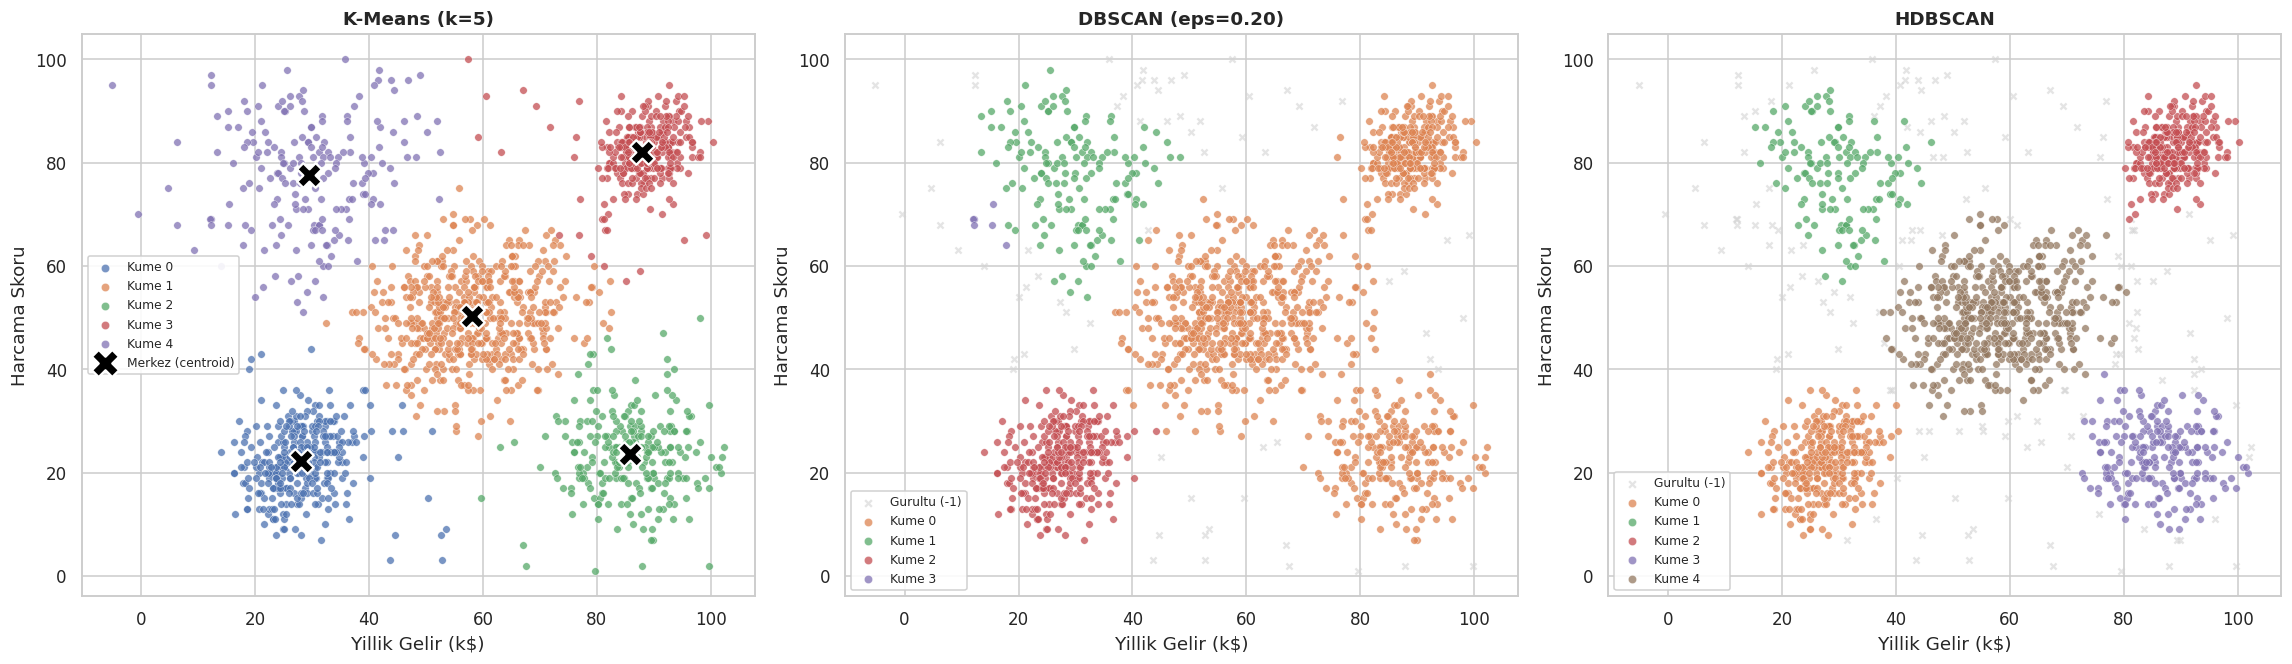

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.2))
plot_clusters(axes[0], km_labels,  "K-Means (k=5)", centroids=centroids_orig)
plot_clusters(axes[1], db_labels,  "DBSCAN (eps=0.20)")
plot_clusters(axes[2], hdb_labels, "HDBSCAN")
fig.tight_layout()
plt.show()

**Okuma:**
- **ARI/AMI:** Veri dışbükey öbeklerden oluştuğu için K-Means doğru `k` ile en yüksek ARI'yi (~0.87) verir — DBSCAN/HDBSCAN'den iyi. Bu, *veri varsayımı uyduğunda* K-Means'in ne kadar güçlü olduğunu gösterir.
- **Gürültü:** K-Means gürültü sütununda **%0** gösterir çünkü ayıramaz; HDBSCAN ~%9'u gürültü olarak işaretleyip segmentleri temiz tutar. Bu, ARI'ye yansımayan ama **iş açısından kritik** bir farktır.
- **Parametre:** K-Means `k`'yi (bulduk: 5), DBSCAN kırılgan `eps`'i gerektirir; HDBSCAN ikisini de büyük ölçüde otomatikleştirir.

**Doğru araç seçimi:**

| Senaryo | Önerilen |
|---|---|
| Küresel kümeler, az gürültü, çok büyük veri, hız öncelikli | **K-Means** |
| Keyfi şekil, gürültü ayrımı gerekli, homojen yoğunluk | **DBSCAN** |
| Değişken yoğunluk + gürültü, minimum parametre ayarı | **HDBSCAN** |


## 12. Sonuç, Sınırlılıklar ve Üretim Notları

### Sonuç
- Beş bağımsız yöntem `k = 5` üzerinde uzlaştı; K-Means bu `k` ile gerçek segmentleri güçlü biçimde (ARI ≈ 0.87) yakaladı ve yorumlanabilir merkezler üretti.
- K-Means'in temel kazancı **hız, basitlik ve yorumlanabilirlik**; temel maliyeti **`k` gereksinimi, dışbükey-küme varsayımı ve gürültüyü ayıramaması**.
- Bu veri kümeleri küresele yakın olduğundan K-Means iyi çalıştı; gerçek dünyada bu varsayım her zaman geçerli değildir — kümeleme öncesi şekil/yoğunluk yapısını EDA ile değerlendirin.

### Sınırlılıklar
- 2 özellikte kümelendi (yorumlanabilirlik için); daha çok değişken ayrımı artırabilir ama küresellik varsayımını zorlar.
- K-Means başlatmaya duyarlıdır → her zaman `k-means++` + `n_init ≥ 10`.
- Aykırı değerler merkezleri çeker; çok aykırılı veride `RobustScaler` veya aykırı temizleme düşünülmeli.
- Dışsal metrikler (ARI/AMI) bu sentetik veriye özgüdür; gerçek projede içsel metrikler + iş yorumu esastır.

### Üretim Notları
- **`k` yönetişimi:** `k`'yi tek seferlik değil, periyodik olarak (çeyreklik) elbow+silhouette ile yeniden doğrulayın.
- **Yeni nokta atama:** `kmeans.predict()` ile yeni müşteriler anında segmentlenir (K-Means'in DBSCAN/HDBSCAN'e göre operasyonel avantajı).
- **Drift izleme:** Merkezlerin ve küme büyüklüklerinin zaman içindeki kaymasını izleyin.
- **Düşük güven:** Merkeze uzaklık yüksek müşterileri ayrı ele alın (yukarıdaki `km_supheli` yaklaşımı).
- **Yüksek boyut:** Önce `PCA`, sonra K-Means; `MiniBatchKMeans` çok büyük veride.
- **İzlenebilirlik:** `k`, ölçekleyici, tohum ve `n_init` sürümlenerek kaydedilmeli (MLflow vb.).